In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import few
from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux
from few.utils.geodesic import get_fundamental_frequencies
from few.utils.constants import YRSID_SI
import os
import sys

# Changing directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Configuration
use_gpu = True
force_backend = "cuda12x"
dt = 10.0  # seconds
T = 2.0  # years (use 2 years for full evolution)

# Waveform generator setup
inspiral_kwargs = {
    "func": 'KerrEccEqFlux',
    "DENSE_STEPPING": 0,
    "include_minus_m": False,
}

amplitude_kwargs = {"force_backend": force_backend}
Ylm_kwargs = {"force_backend": force_backend}
sum_kwargs = {
    "force_backend": force_backend,
    "pad_output": True,
}

waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)




In [2]:
# Source parameters 
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5


params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

In [3]:
print("Generating waveform...")
h = waveform_gen(*params, T=T, dt=dt)

Generating waveform...


In [4]:
import GWfuncs

gwf = GWfuncs.GravWaveAnalysis(T, dt)
gwf.rhostat(h)

array(32.86622401)

In [5]:
h_real = h.real
h_real

array([ 9.61129693e-23,  1.10597589e-22,  1.19863555e-22, ...,
        3.34213094e-23, -7.24591444e-23, -1.64822999e-22],
      shape=(6311630,))

In [6]:
print(f"Signal length: {len(h_real)} samples")
print(f"Duration: {len(h_real) * dt / YRSID_SI:.2f} years")


Signal length: 6311630 samples
Duration: 2.00 years


In [7]:
# Generate trajectory to get fundamental frequencies
print("Computing fundamental frequencies...")
from few.trajectory.inspiral import EMRIInspiral
N_traj = 5000
delta_T = T*YRSID_SI/5000
traj_gen = EMRIInspiral(func='KerrEccEqFlux')
t_arr, p_arr, e_arr, x_arr, Phi_phi_arr, Phi_theta_arr, Phi_r_arr = traj_gen(
    m1, m2, a, p0, e0, xI0, T=T, dt=dt, upsample=True,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0
)

Computing fundamental frequencies...


In [8]:
from few.utils.utility import get_p_at_t

get_p_at_t(traj_module=traj_gen, t_out=T, traj_args=[m1, m2, a, e0, xI0])


8.965984867881014

In [9]:
p_arr, e_arr

(array([9.        , 8.99999969, 8.99999938, ..., 4.39302308, 4.39301882,
        4.39301456], shape=(6311629,)),
 array([0.4       , 0.39999998, 0.39999996, ..., 0.13481857, 0.1348184 ,
        0.13481824], shape=(6311629,)))

In [10]:
len(p_arr)

6311629

In [11]:

# Get fundamental frequencies along trajectory
freqs_list = []
for p_val, e_val in zip(p_arr, e_arr):
    Om_phi, Om_theta, Om_r = get_fundamental_frequencies(a, p_val, e_val, xI0)
    freqs_list.append([Om_phi, Om_theta, Om_r])

freqs_list

[[0.029413902437296593, 0.028089353426629694, 0.021191001975987656],
 [0.02941390469119864, 0.02808935551606249, 0.021191003325746506],
 [0.029413906945033635, 0.028089357605494022, 0.02119100467550441],
 [0.029413909198813325, 0.02808935969493659, 0.02119100602527057],
 [0.029413911452638067, 0.028089361784357947, 0.021191007375020506],
 [0.029413913706520564, 0.028089363873805017, 0.021191008724789937],
 [0.02941391596035322, 0.02808936596323246, 0.021191010074544336],
 [0.029413918214152252, 0.028089368052667905, 0.02119101142430475],
 [0.029413920468030114, 0.028089370142100924, 0.02119101277406336],
 [0.029413922721802217, 0.028089372231547394, 0.021191014123831852],
 [0.029413924975633884, 0.02808937432097805, 0.02119101547358838],
 [0.02941392722948482, 0.028089376410418868, 0.02119101682335253],
 [0.02941392948337179, 0.028089378499841628, 0.02119101817310311],
 [0.029413931737170166, 0.02808938058929241, 0.021191019522874645],
 [0.029413933991004917, 0.02808938267872659, 0.021

In [12]:
freqs_arr = np.array(freqs_list)
from few.utils.constants import MTSUN_SI
M = m1+m2
Msec = M * MTSUN_SI  # Total mass in seconds
freq_phi = freqs_arr[:, 0] / (2 * np.pi * Msec)  # Convert to Hz
freq_theta = freqs_arr[:, 1] / (2 * np.pi * Msec)
freq_r = freqs_arr[:, 2] / (2 * np.pi * Msec)

In [13]:
modes = [
    (l, m, n) 
    for l in range(2, 4) 
    for m in range(-l, l + 1)
    for n in range(-1,6)
]

# Compute mode frequencies
mode_freqs = []
for l, m, n in modes:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs.append(f_mode)

In [14]:
## INCLUDE FOR ALL M 
# just np range 
# 

modes_l2= [
    (2, m, n) 
    for m in range(-2, 3)
    for n in range(-1,6)
]



modes_l3= [
    (3, m, n) 
    for m in range(-3, 4)
    for n in range(-1,6)
]

mode_freqs_l2 = []
for l, m, n in modes_l2:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs_l2.append(f_mode)

mode_freqs_l3 = []
for l, m, n in modes_l3:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs_l3.append(f_mode)

In [15]:
h_l2 = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l2, include_minus_mkn=False)
h_l3 = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l3, include_minus_mkn=False)

In [16]:
fs = 1.0/dt
nperseg = 2**16  
noverlap = nperseg * 3 // 4  # 

# nperseg = 2**14
# noverlap = nperseg // 2
f_l2, t_l2, Zxx_l2 = signal.stft(h_l2.get(), fs=fs, nperseg=nperseg, noverlap=noverlap, window='hann')
f_l3, t_l3, Zxx_l3 = signal.stft(h_l3.get(), fs=fs, nperseg=nperseg, noverlap=noverlap, window='hann')



/tmp/ipykernel_410487/809106386.py:7: UserWarning: Input data is complex, switching to return_onesided=False
  f_l2, t_l2, Zxx_l2 = signal.stft(h_l2.get(), fs=fs, nperseg=nperseg, noverlap=noverlap, window='hann')
/tmp/ipykernel_410487/809106386.py:8: UserWarning: Input data is complex, switching to return_onesided=False
  f_l3, t_l3, Zxx_l3 = signal.stft(h_l3.get(), fs=fs, nperseg=nperseg, noverlap=noverlap, window='hann')


In [17]:
Zxx_l2

array([[ 1.69991775e-26-1.31881990e-26j,  8.49557293e-27-6.59694012e-27j,
        -1.47392598e-32-3.05856790e-32j, ...,
         2.34007935e-27-3.72181017e-27j,  7.02058023e-27-1.11720885e-26j,
         4.91695921e-27-7.82747917e-27j],
       [-1.69935041e-26+1.31801035e-26j, -6.59296384e-27-8.49271686e-27j,
        -1.48290364e-32-3.07095446e-32j, ...,
         4.30963263e-27+8.64512815e-28j, -2.59149315e-27+1.29352406e-26j,
        -9.06213409e-27-1.81393815e-27j],
       [ 1.69877165e-26-1.31720510e-26j, -8.48982904e-27+6.58890412e-27j,
        -1.49238519e-32-3.08512188e-32j, ...,
         7.23322375e-28+4.33469687e-27j, -2.17413003e-27-1.30092933e-26j,
         1.52464404e-27+9.11344442e-27j],
       ...,
       [-1.70160607e-26+1.32118851e-26j, -6.60876435e-27-8.50412219e-27j,
        -1.44972731e-32-3.03155611e-32j, ...,
        -3.53487209e-28+4.38468804e-27j, -1.31601292e-26-1.05768349e-27j,
         7.39394680e-28-9.21949796e-27j],
       [ 1.70104565e-26-1.32040896e-26j, -8.

In [18]:
f, t, Zxx = signal.stft(h_real.get(), fs=fs, 
                               nperseg=nperseg, noverlap=noverlap, 
                               return_onesided=False)



In [19]:
t_years = t / YRSID_SI
T_total = len(h_real) * dt / YRSID_SI
t_years_adjusted = t_years - T_total  # t_p - 2y to t_p

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_410487/2509533578.py:4: SyntaxWarning: invalid escape sequence '\e'
  labels_l2 = ['$t_p - 2y$ ($\ell=2$)', '$t_p - 3m$  ($\ell=2$)', '$t_p - 1d$  ($\ell=2$)']
/tmp/ipykernel_410487/2509533578.py:4: SyntaxWarning: invalid escape sequence '\e'
  labels_l2 = ['$t_p - 2y$ ($\ell=2$)', '$t_p - 3m$  ($\ell=2$)', '$t_p - 1d$  ($\ell=2$)']
/tmp/ipykernel_410487/2509533578.py:4: SyntaxWarni

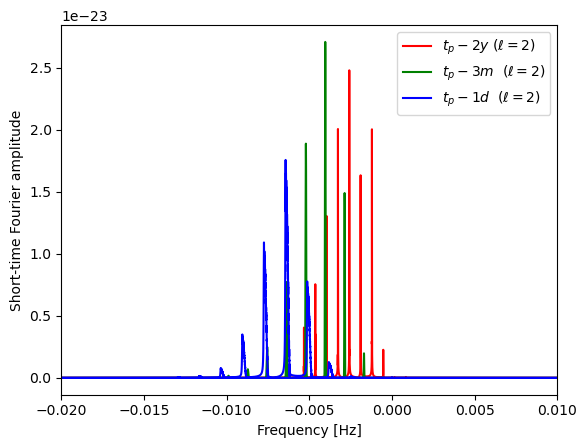

In [42]:
times_before_plunge = [2.0, 3/12, 1/365.25]  # 2y, 3m, 1d
colors_l2 = ['red', 'green', 'blue']
colors_l3 = ['orange', 'lightseagreen', 'purple']
labels_l2 = ['$t_p - 2y$ ($\ell=2$)', '$t_p - 3m$  ($\ell=2$)', '$t_p - 1d$  ($\ell=2$)']
labels_l3 = ['$t_p - 2y$ ($\ell=3$)', '$t_p - 3m$ ($\ell=3$)', '$t_p - 1d$ ($\ell=3$)']

fig, ax = plt.subplots()

for time_bp, color_l2, color_l3, label_l2, label_l3 in zip(times_before_plunge, colors_l2, colors_l3, labels_l2, labels_l3):
    target_time = -time_bp
    idx = np.argmin(np.abs(t_years_adjusted - target_time))
    # amplitude = np.sqrt(Sxx[:, idx])
    amplitude_l2 = np.abs(Zxx_l2[:, idx]) 
    # amplitude_l3 = np.abs(Zxx_l3[:, idx])  

    ax.plot(f_l2, amplitude_l2, color=color_l2, label=label_l2, linewidth=1.5)
    # ax.plot(f_l3, amplitude_l3, color=color_l3, label=label_l3, linewidth=1.5)


ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Short-time Fourier amplitude')
ax.set_xlim([-0.02, 0.01])
# ax.set_ylim([0, 2.5*10**(-24)]) 
ax.legend()

In [23]:
T,dt

(2.0, 10.0)

In [24]:
snr_full = gwf.rhostat(h)
snr_full

array(32.86622401)

In [25]:
snr_l2 = gwf.rhostat(h_l2)
snr_l2 

array(30.82544563)

In [26]:
p_l2 = gwf.rhostat(h_l2)**2/gwf.rhostat(h)**2 * 100
p_l2

array(87.96686313)

In [27]:
snr_l3 = gwf.rhostat(h_l3)
snr_l3

array(0.42733171)

In [28]:
p_l3 = gwf.rhostat(h_l3)**2 /gwf.rhostat(h)**2 *100
p_l3

array(0.0169056)

In [29]:
p_l2+p_l3

array(87.98376873)

In [33]:
modes_l2_all = [
    (2, m, n) 
    for m in range(-2,3)
    for n in range(-55,56)
]
modes_l2_all
h = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l2_all, include_minus_mkn=False)

(ModeSelector) Warning: Mode selection is large. Instantiate class with mode selection rather than providing it at call time for better performance.


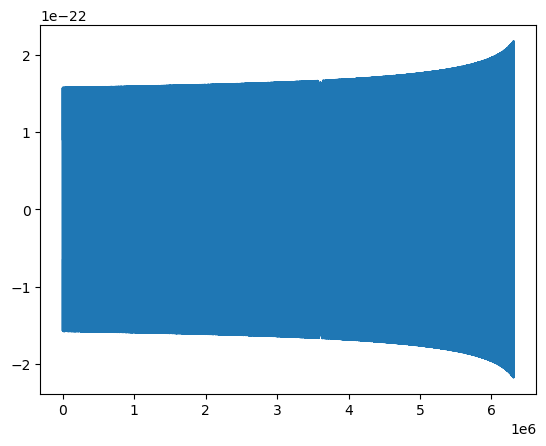

In [34]:
h_real = h.real

plt.plot(h_real.get())
plt.show()

In [35]:
fs = 1.0 / dt  # Sampling frequency
nperseg = 2**16  # Window size for STFT
noverlap = nperseg * 3 // 4

f, t, Zxx = signal.stft(h_real.get(), fs=fs, 
                               nperseg=nperseg, noverlap=noverlap, 
                               return_onesided=True) #NOTE: set True

# Zxx = scipy.fft.fftshift(Zxx, axes=0)
# f = scipy.fft.fftshift(f)

# t_years = t / YRSID_SI
# T_total = len(h_real) * dt / YRSID_SI
# t_years_adjusted = t_years - T_total  # t_p - 2y to t_p

t_traj_years = t_arr - t_arr[0] 

log_amp = np.log10(np.abs(Zxx))
max_val = np.max(log_amp)
# NOTE: change ord of magnitude
vmin_val = max_val - 6
t_spec_seconds = t - t[0] 

extent = [t_spec_seconds[0], t_spec_seconds[-1], f[0], f[-1]]

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_410487/4066895820.py:11: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")


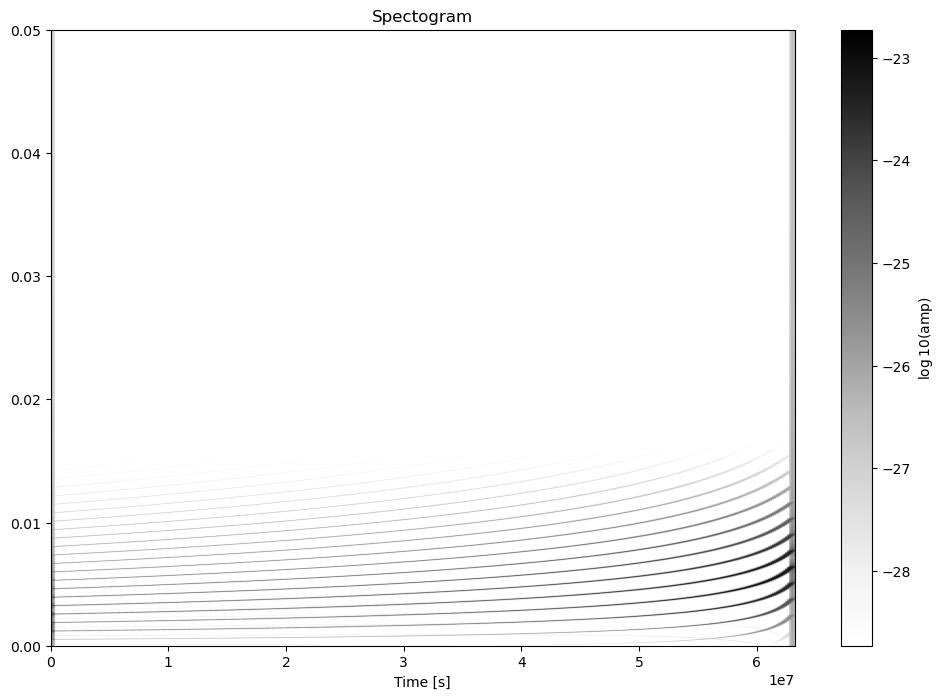

In [36]:
# STFT amplitudes only
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)
cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")
plt.xlabel('Time [s]')
plt.title('Spectogram')
plt.show()

In [37]:
from collections import defaultdict

# sum frequencies for each (l, n)
mode_groups = defaultdict(list)
for i, (ell, m, n) in enumerate(modes):
    mode_groups[(ell, n)].append(mode_freqs[i])
summed_freqs = {}
for (ell, n), freq_list in mode_groups.items():
    summed_freqs[(ell, n)] = np.sum(freq_list, axis=0)


<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\e'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_410487/3809841431.py:44: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/tmp/ipykernel_410487/3809841431.py:48: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Spectogram vs Frequency tracks $\ell=2$ and $n=1$')
/tmp/ipykernel_410487/3809841431.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')


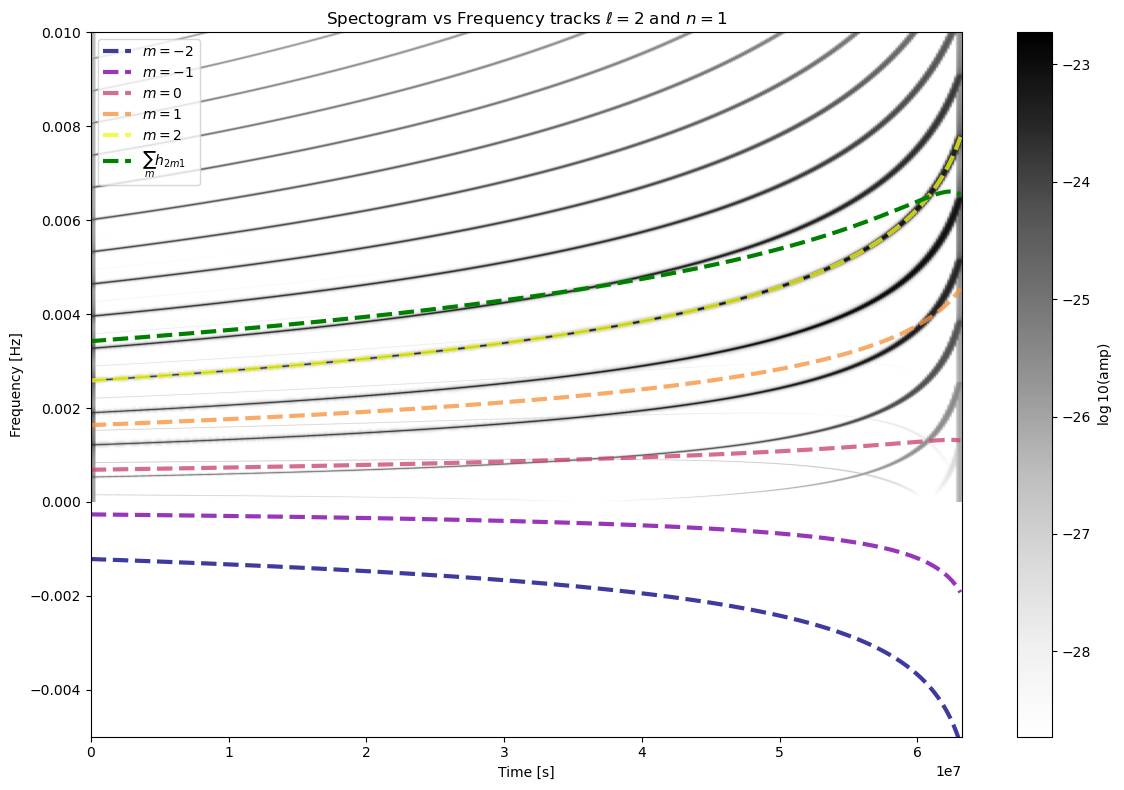

In [38]:
import matplotlib.cm as cm

# Spectogram 
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)

m_values = np.arange(-2, 3) 
cmap = cm.get_cmap('plasma') 
colors = cmap(np.linspace(0, 1, len(m_values)))

for i, mode in enumerate(modes):
    ell, m, n = mode
    lstyle = 'dashed'
    linewidth = 3
    label = f'$m={m}$'
    if ell == 2 and n == 1:
        color_idx = m + 2  # Map m to color index
        plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=colors[color_idx], linewidth=linewidth, alpha=0.8, label=label)


# # plot each m for (ell=2,n=1)
# for i in range(len(modes)):
#     ell, m, n = modes[i]
#     col = 'red'
#     lstyle = 'dashed'
#     linewidth=3
#     label = f'$m={m}$'
#     if ell==2 and n==1:
#         plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=col,linewidth=linewidth, alpha=0.8, label=label)
# plot summed freqs for (ell=2, n=1)
# colors = plt.cm.tab10(np.linspace(0, 1, len(summed_freqs)))
for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
    label = r'$\sum_m h_{2m1}$'
    if ell == 2 and n==1:
        plt.plot(t_traj_years, freq, color='green', linewidth=3, linestyle='dashed', alpha=1, label=label)

cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectogram vs Frequency tracks $\ell=2$ and $n=1$')
plt.ylim(-0.005,0.01)

plt.legend(loc='best')
plt.tight_layout()
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_410487/2120802289.py:34: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/tmp/ipykernel_410487/2120802289.py:38: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Spectogram vs Frequency tracks $\ell=2$ and $m=2$')
/tmp/ipykernel_410487/2120802289.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('winter')


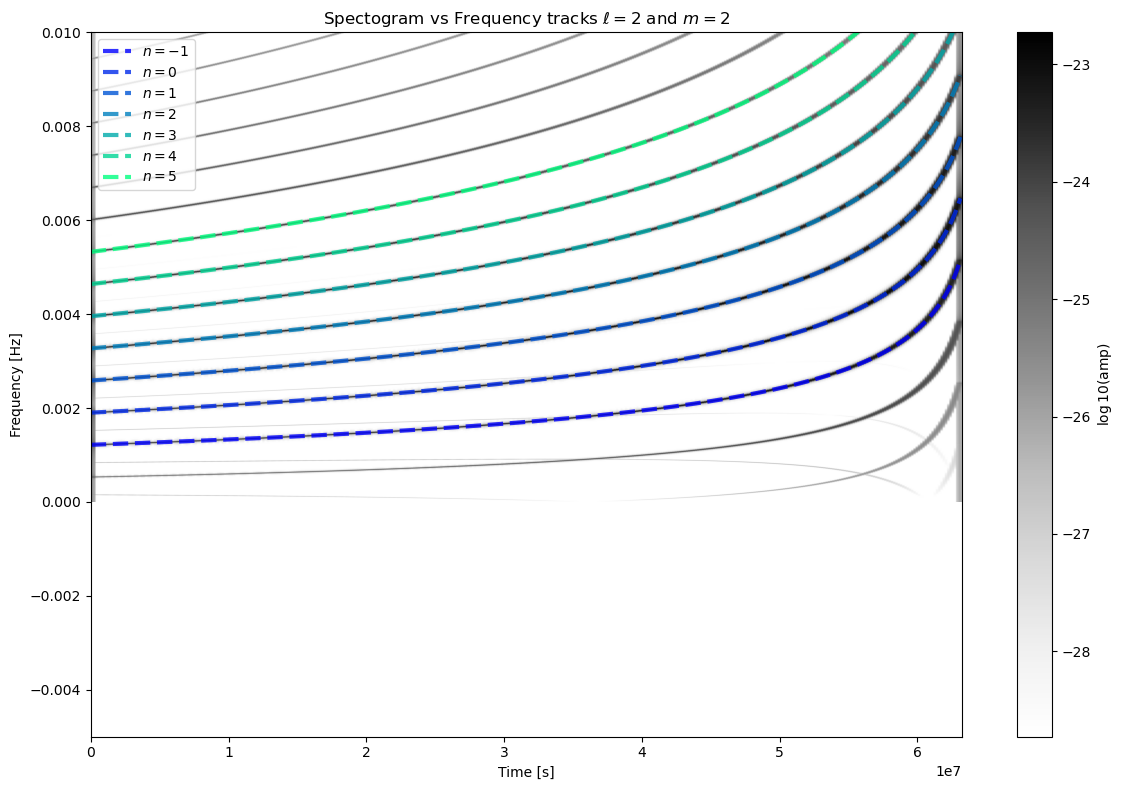

In [39]:

# Spectogram 
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)



# NOTE: plot each n for (ell=2,m=2)
n_values = np.arange(-1, 6) 
cmap = cm.get_cmap('winter') 
colors = cmap(np.linspace(0, 1, len(n_values)))

for i, mode in enumerate(modes):
    ell, m, n = mode
    lstyle = 'dashed'
    linewidth = 3
    label = f'$n={n}$'
    if ell == 2 and m == 2:
        color_idx = n + 1  
        plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=colors[color_idx], linewidth=linewidth, alpha=0.8, label=label)

# plot summed freqs for (ell=2, n=1)
# for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
#     label = f'$(\ell={ell}, n={n})$'
#     if ell == 2 and n==1:
#         plt.plot(t_traj_years, freq, color='green', linewidth=3, linestyle='dashed', alpha=1, label=label)

cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectogram vs Frequency tracks $\ell=2$ and $m=2$')
plt.ylim(-0.005,0.01)

plt.legend(loc='best')
plt.tight_layout()
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_410487/314335290.py:34: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/tmp/ipykernel_410487/314335290.py:38: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Spectogram vs Frequency tracks $\ell=2$ and $m=1$')
/tmp/ipykernel_410487/314335290.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


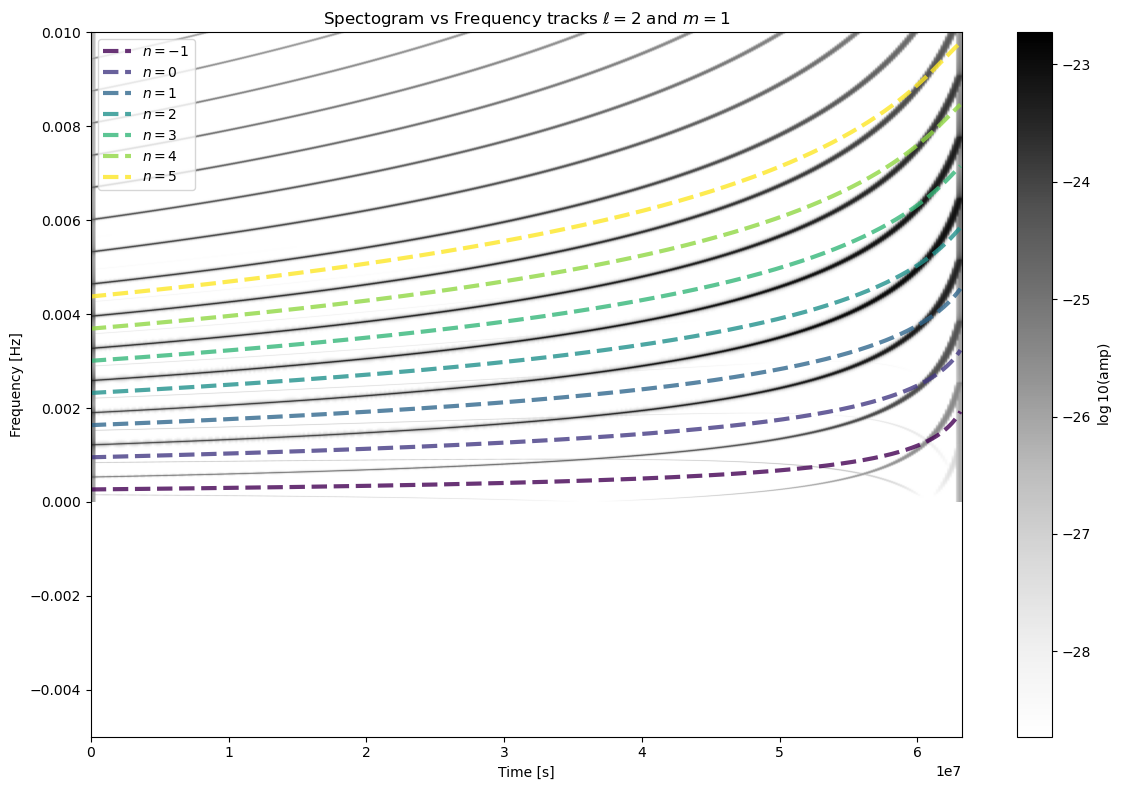

In [40]:

# Spectogram 
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)



# NOTE: plot each n for (ell=2,m=2)
n_values = np.arange(-1, 6) 
cmap = cm.get_cmap('viridis') 
colors = cmap(np.linspace(0, 1, len(n_values)))

for i, mode in enumerate(modes):
    ell, m, n = mode
    lstyle = 'dashed'
    linewidth = 3
    label = f'$n={n}$'
    if ell == 2 and m == 1:
        color_idx = n + 1  
        plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=colors[color_idx], linewidth=linewidth, alpha=0.8, label=label)

# plot summed freqs for (ell=2, n=1)
# for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
#     label = f'$(\ell={ell}, n={n})$'
#     if ell == 2 and n==1:
#         plt.plot(t_traj_years, freq, color='green', linewidth=3, linestyle='dashed', alpha=1, label=label)

cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectogram vs Frequency tracks $\ell=2$ and $m=1$')
plt.ylim(-0.005,0.01)

plt.legend(loc='best')
plt.tight_layout()
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_410487/3790677791.py:34: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/tmp/ipykernel_410487/3790677791.py:38: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Spectogram vs Frequency tracks $\ell=2$ and $m=0$')
/tmp/ipykernel_410487/3790677791.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('winter')


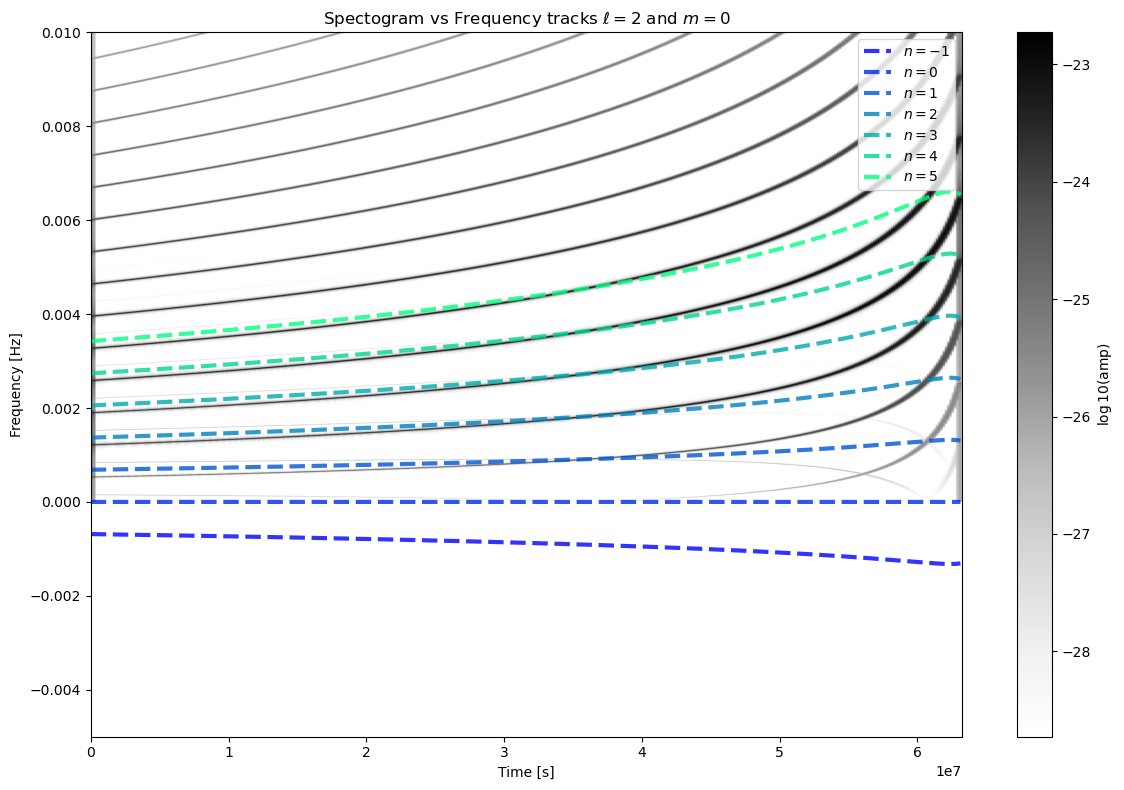

In [41]:

# Spectogram 
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)



# NOTE: plot each n for (ell=2,m=2)
n_values = np.arange(-1, 6) 
cmap = cm.get_cmap('winter') 
colors = cmap(np.linspace(0, 1, len(n_values)))

for i, mode in enumerate(modes):
    ell, m, n = mode
    lstyle = 'dashed'
    linewidth = 3
    label = f'$n={n}$'
    if ell == 2 and m == 0:
        color_idx = n + 1  
        plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=colors[color_idx], linewidth=linewidth, alpha=0.8, label=label)

# plot summed freqs for (ell=2, n=1)
# for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
#     label = f'$(\ell={ell}, n={n})$'
#     if ell == 2 and n==1:
#         plt.plot(t_traj_years, freq, color='green', linewidth=3, linestyle='dashed', alpha=1, label=label)

cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectogram vs Frequency tracks $\ell=2$ and $m=0$')
plt.ylim(-0.005,0.01)

plt.legend(loc='best')
plt.tight_layout()
plt.show()